<a href="https://colab.research.google.com/github/botirbekzulf-sudo/ML/blob/main/%D0%A3%D1%80%D0%BE%D0%BA13_%D1%81%D0%B0%D0%BC%D0%BE%D1%81%D1%82%D0%BE%D1%8F%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Урок 13 — Самостоятельная работа: первая нейросеть

### Как работать
Читай · запускай по порядку · выполняй задания 📝 · отвечай словами ✍️.

> 🎯 К концу урока ты сможешь объяснить, что делает нейрон, и обучишь свою первую сеть.

**Сначала поиграй в браузере:** открой [playground.tensorflow.org](https://playground.tensorflow.org), нажми ▶ и посмотри, как сеть учится.

## Шаг 1 · Нейрон своими руками
Нейрон умножает входы на веса, складывает и решает «да/нет» по порогу.

### 📝 Задание
Подбери `веса` и `порог` так, чтобы нейрон брал в команду только сильных игроков (сила ≥ 7).

In [24]:
import numpy as np
игрок = np.array([6, 6])        # [сила, скорость]
веса  = np.array([10, 0])    # 👈 меняй
порог = 7                       # 👈 меняй
сумма = np.dot(игрок, веса)
print('решение:', 100 if сумма >= порог else 0, '(1 = берём)')

решение: 100 (1 = берём)


✍️ **Ответь.** Какой признак ты сделал важнее и почему?

*Ответ:* … порог 7 сила [6, 6] весс [10, 0] всял 100 игроков. важнее вес

## Шаг 2 · Твоя первая сеть
Запусти — сеть научится разделять две «луны».

In [8]:
from sklearn.datasets import make_moons
from tensorflow import keras
X, y = make_moons(n_samples=400, noise=0.2, random_state=42)
model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(8, activation='relu'),   # 👈 скрытый слой
    keras.layers.Dense(1, activation='sigmoid'),
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X, y, epochs=50, verbose=0)
print(f'Точность: {history.history["accuracy"][-1]:.0%}')

Точность: 83%


## Шаг 3 · Как сеть училась
Посмотри на кривую: ошибка вниз, точность вверх.

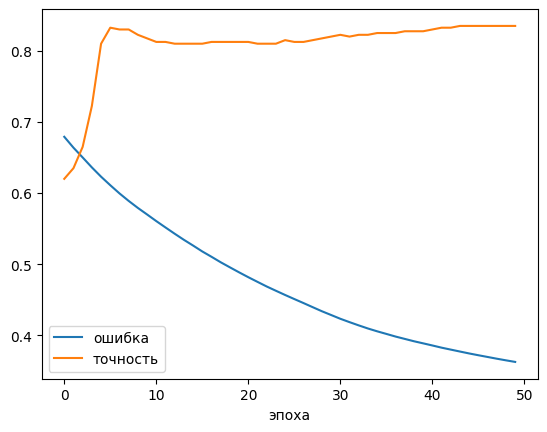

In [26]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='ошибка')
plt.plot(history.history['accuracy'], label='точность')
plt.xlabel('эпоха'); plt.legend(); plt.show()

✍️ **Вопрос.** Примерно на какой эпохе точность перестаёт заметно расти?

*Ответ:* … 7-8

### 📝 Задание — поэкспериментируй
Меняй число нейронов (`units`) и число эпох. Как меняется точность?

In [13]:
units = 9999     # 👈 меняй (2, 8, 16, 64)
epochs = 99    # 👈 меняй (10, 50, 100)
net = keras.Sequential([keras.Input(shape=(2,)),
    keras.layers.Dense(units, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')])
net.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
h = net.fit(X, y, epochs=epochs, verbose=0)
print(f'{units} нейронов, {epochs} эпох -> точность {h.history["accuracy"][-1]:.0%}')

9999 нейронов, 99 эпох -> точность 96%


## ✅ Проверь себя
1. Что делает нейрон?
2. Что такое эпоha?
3. Что значит «сеть учится»?

<details><summary>Ответы</summary>

1. Умножает входы на веса, складывает, решает через активацию.
2. Один полный проход по всем данным.
3. Подкручивает веса, чтобы ошибка становилась меньше.
</details>

## 🏁 Финальное задание (3 уровня)
**Базовый.** Обучи сеть и выведи точность.
**Средний.** Найди наименьшее число нейронов, дающее точность ≥ 85%.
**Продвинутый.** Нарисуй границу решения (код ниже).

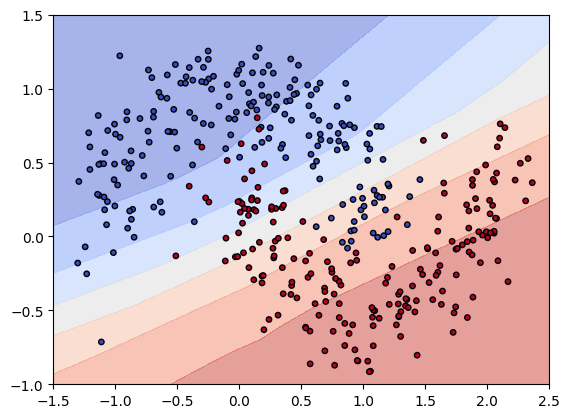

In [12]:
import numpy as np, matplotlib.pyplot as plt
xx, yy = np.meshgrid(np.linspace(-1.5,2.5,150), np.linspace(-1,1.5,150))
zz = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0).reshape(xx.shape)
plt.contourf(xx, yy, zz, alpha=0.5, cmap='coolwarm')
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k', s=15); plt.show()

---
### 🎉 Готово!
Ты обучил первую нейросеть. На следующем уроке она научится узнавать рукописные цифры!